In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from lmfit import Model
import pathlib as Path
from scipy.signal import savgol_filter

import src.modeling as mod

In [2]:
from pathlib import Path
x = Path('/Users/arthur/Library/Mobile Documents/com~apple~CloudDocs/Documents/Marseille/aMU/M1/Stage/2026_08_08_data_timeseries.csv')
df = pd.read_csv(x)
df

,condition_id,condition,category,valence,time,LDX (pix),LDY (pix),RDX (pix),RDY (pix)
0,ACP_10,ACP,objet,negative,0.000000,-0.203103,10.545351,-1.557942,7.259980
1,ACP_10,ACP,objet,negative,0.003335,0.411109,11.118102,-0.912476,7.956384
2,ACP_10,ACP,objet,negative,0.006670,1.032096,11.620336,-0.216857,8.562834
3,ACP_10,ACP,objet,negative,0.010006,1.631694,11.941326,0.494356,8.978518
4,ACP_10,ACP,objet,negative,0.013341,2.171882,11.973220,1.177103,9.107632
...,...,...,...,...,...,...,...,...,...
933627,DFT_9,DFT,visage,positive,5.959993,NaN,NaN,-23.547614,NaN
933628,DFT_9,DFT,visage,positive,5.963328,NaN,NaN,-24.026216,NaN
933629,DFT_9,DFT,visage,positive,5.966663,NaN,NaN,-24.564667,NaN
933630,DFT_9,DFT,visage,positive,5.969998,NaN,NaN,-25.144319,NaN


In [3]:
df['RDX_rolling'] = df.groupby(['condition_id', 'category', 'valence'])['RDX (pix)'].transform(
    lambda x: x.rolling(window=20, min_periods=1).mean()
)

latence au minimum, latence au maximum, pente de dilatation (2–4 s)

In [4]:
df['RDX_min'] = df.groupby(['condition_id', 'category', 'valence'])['RDX_rolling'].transform(
    lambda x: x.iloc[50:500].min()
)

df['RDX_lat_min'] = df.groupby(['condition_id', 'category', 'valence'])['RDX_rolling'].transform(
    lambda x: x.iloc[50:500].argmin() + 50 if x.notna().any() else None
)

df['RDX_max'] = df.groupby(['condition_id', 'category', 'valence'])['RDX_rolling'].transform(
    lambda x: x.iloc[400:1750].max()
)

df['RDX_lat_max'] = df.groupby(['condition_id', 'category', 'valence'])['RDX_rolling'].transform(
    lambda x: x.iloc[400:1750].argmax() + 400 if x.notna().any() else None
)

# # gradient of curve between 2 and 4 seconds
# df['RDX_grad'] = df.groupby(['condition_id', 'category', 'valence'])['RDX_rolling'].transform(
#     lambda x: (x.iloc[1200]-x.iloc[300])/900 if x.notna().any() else None
# )

df['RDX_grad'] = (df.RDX_max - df.RDX_min)/(df.RDX_lat_max - df.RDX_lat_min)

In [5]:
df

,condition_id,condition,category,valence,time,LDX (pix),LDY (pix),RDX (pix),RDY (pix),RDX_rolling,RDX_min,RDX_lat_min,RDX_max,RDX_lat_max,RDX_grad,RDX_slope
0,ACP_10,ACP,objet,negative,0.000000,-0.203103,10.545351,-1.557942,7.259980,-1.557942,-44.339866,329.0,-12.022054,1655.0,0.015888,0.024372
1,ACP_10,ACP,objet,negative,0.003335,0.411109,11.118102,-0.912476,7.956384,-1.235209,-44.339866,329.0,-12.022054,1655.0,0.015888,0.024372
2,ACP_10,ACP,objet,negative,0.006670,1.032096,11.620336,-0.216857,8.562834,-0.895758,-44.339866,329.0,-12.022054,1655.0,0.015888,0.024372
3,ACP_10,ACP,objet,negative,0.010006,1.631694,11.941326,0.494356,8.978518,-0.548230,-44.339866,329.0,-12.022054,1655.0,0.015888,0.024372
4,ACP_10,ACP,objet,negative,0.013341,2.171882,11.973220,1.177103,9.107632,-0.203163,-44.339866,329.0,-12.022054,1655.0,0.015888,0.024372
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
933627,DFT_9,DFT,visage,positive,5.959993,NaN,NaN,-23.547614,NaN,-23.149807,-48.965409,317.0,-13.618955,1256.0,0.028713,0.037643
933628,DFT_9,DFT,visage,positive,5.963328,NaN,NaN,-24.026216,NaN,-23.152393,-48.965409,317.0,-13.618955,1256.0,0.028713,0.037643
933629,DFT_9,DFT,visage,positive,5.966663,NaN,NaN,-24.564667,NaN,-23.182579,-48.965409,317.0,-13.618955,1256.0,0.028713,0.037643
933630,DFT_9,DFT,visage,positive,5.969998,NaN,NaN,-25.144319,NaN,-23.244083,-48.965409,317.0,-13.618955,1256.0,0.028713,0.037643


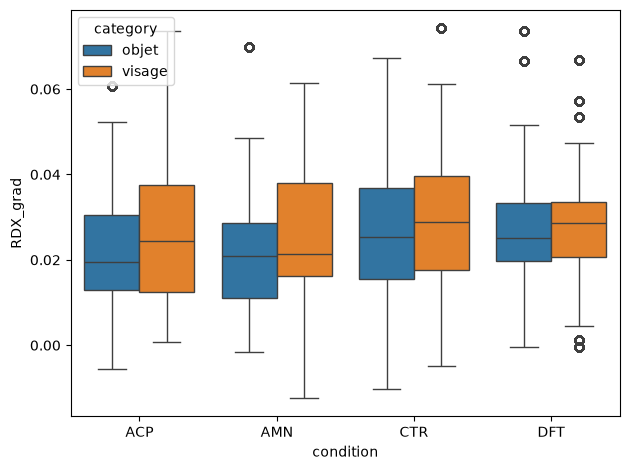

In [21]:
sns.boxplot(df, x='condition', y='RDX_grad', hue='category')
plt.tight_layout()
# sns.boxplot?

In [5]:
df

,condition_id,condition,category,valence,time,LDX (pix),LDY (pix),RDX (pix),RDY (pix),RDX_rolling,RDX_min,RDX_lat_min,RDX_max,RDX_lat_max,RDX_grad
0,ACP_10,ACP,objet,negative,0.000000,-0.203103,10.545351,-1.557942,7.259980,-1.557942,-44.339866,329.0,-12.022054,1655.0,0.024372
1,ACP_10,ACP,objet,negative,0.003335,0.411109,11.118102,-0.912476,7.956384,-1.235209,-44.339866,329.0,-12.022054,1655.0,0.024372
2,ACP_10,ACP,objet,negative,0.006670,1.032096,11.620336,-0.216857,8.562834,-0.895758,-44.339866,329.0,-12.022054,1655.0,0.024372
3,ACP_10,ACP,objet,negative,0.010006,1.631694,11.941326,0.494356,8.978518,-0.548230,-44.339866,329.0,-12.022054,1655.0,0.024372
4,ACP_10,ACP,objet,negative,0.013341,2.171882,11.973220,1.177103,9.107632,-0.203163,-44.339866,329.0,-12.022054,1655.0,0.024372
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
933627,DFT_9,DFT,visage,positive,5.959993,NaN,NaN,-23.547614,NaN,-23.149807,-48.965409,317.0,-13.618955,1256.0,0.037643
933628,DFT_9,DFT,visage,positive,5.963328,NaN,NaN,-24.026216,NaN,-23.152393,-48.965409,317.0,-13.618955,1256.0,0.037643
933629,DFT_9,DFT,visage,positive,5.966663,NaN,NaN,-24.564667,NaN,-23.182579,-48.965409,317.0,-13.618955,1256.0,0.037643
933630,DFT_9,DFT,visage,positive,5.969998,NaN,NaN,-25.144319,NaN,-23.244083,-48.965409,317.0,-13.618955,1256.0,0.037643


In [7]:
df.to_csv('2026_09_09_data_timeseries.csv')